# Fuel Price Prediction 

In [1]:
import pandas as pd
import numpy as np

# Gorsellestirme
import matplotlib.pyplot as plt
import seaborn as sns

# On isleme ve Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

### 1. Veri Setini Yukleme

In [2]:
df = pd.read_csv('global_fuel_prices_2020_2026.csv')
print(f"Veri Boyutu: {df.shape}")
df.head()

Veri Boyutu: (27468, 10)


,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


### 1.5. Kesifci Veri Analizi (Exploratory Data Analysis - EDA)

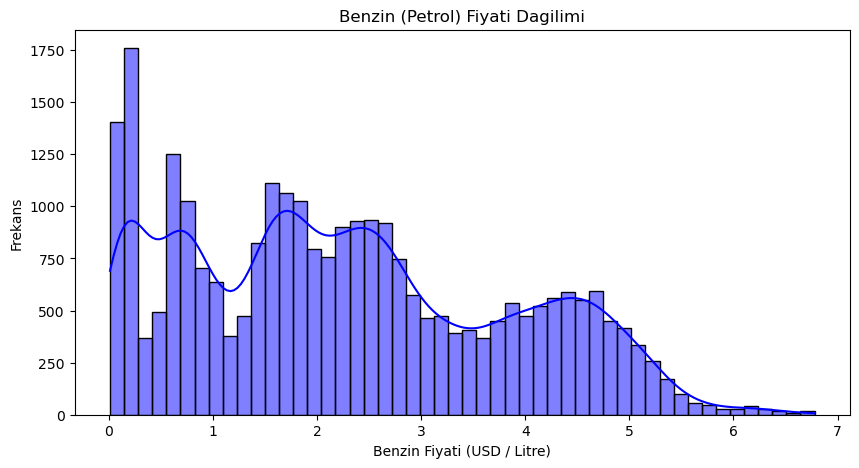

In [3]:
# 1. Fiyat Dagilim Grafigi (Distribution of Petrol Prices)
plt.figure(figsize=(10, 5))
sns.histplot(df['petrol_usd_liter'], kde=True, bins=50, color='blue')
plt.title('Benzin (Petrol) Fiyati Dagilimi')
plt.xlabel('Benzin Fiyati (USD / Litre)')
plt.ylabel('Frekans')
plt.show()

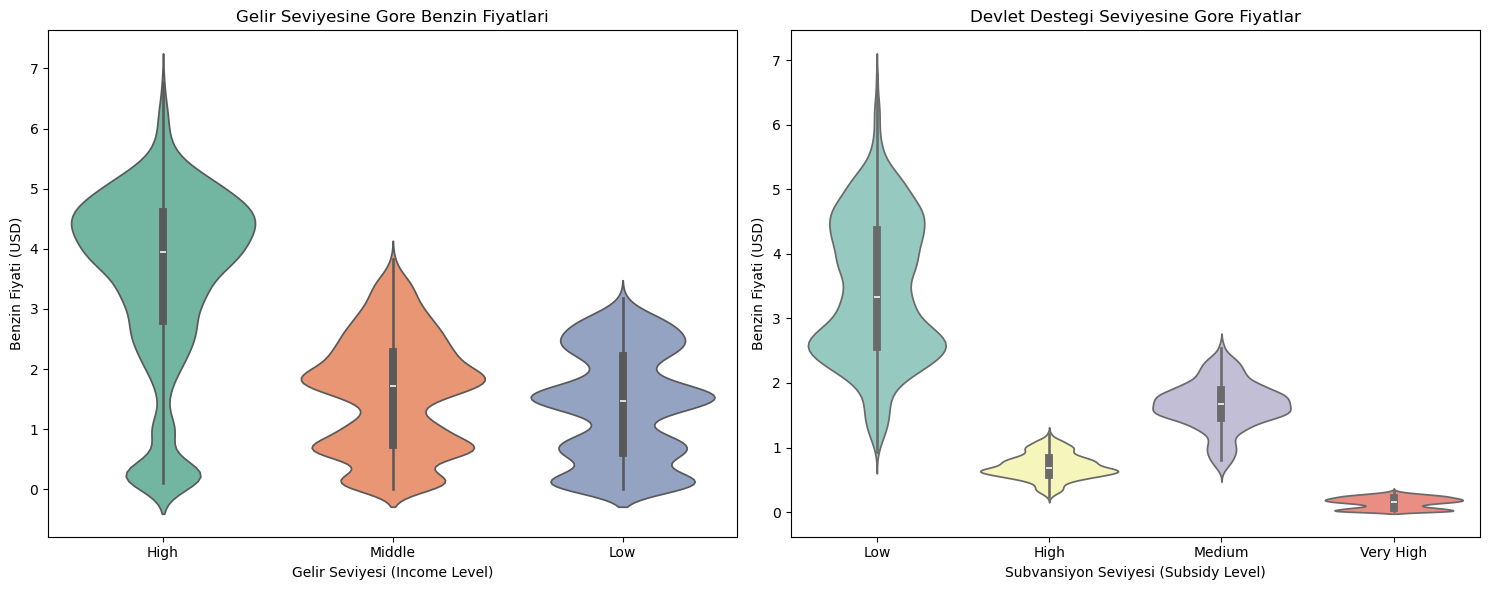

In [4]:
# 2. Gelir Seviyesi ve Subvansiyonlara Gore Fiyatlarin Karsilastirilmasi (Violin Plots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(ax=axes[0], data=df, x='income_level', y='petrol_usd_liter', palette='Set2')
axes[0].set_title('Gelir Seviyesine Gore Benzin Fiyatlari')
axes[0].set_xlabel('Gelir Seviyesi (Income Level)')
axes[0].set_ylabel('Benzin Fiyati (USD)')

sns.violinplot(ax=axes[1], data=df, x='subsidy_level', y='petrol_usd_liter', palette='Set3')
axes[1].set_title('Devlet Destegi Seviyesine Gore Fiyatlar')
axes[1].set_xlabel('Subvansiyon Seviyesi (Subsidy Level)')
axes[1].set_ylabel('Benzin Fiyati (USD)')

plt.tight_layout()
plt.show()

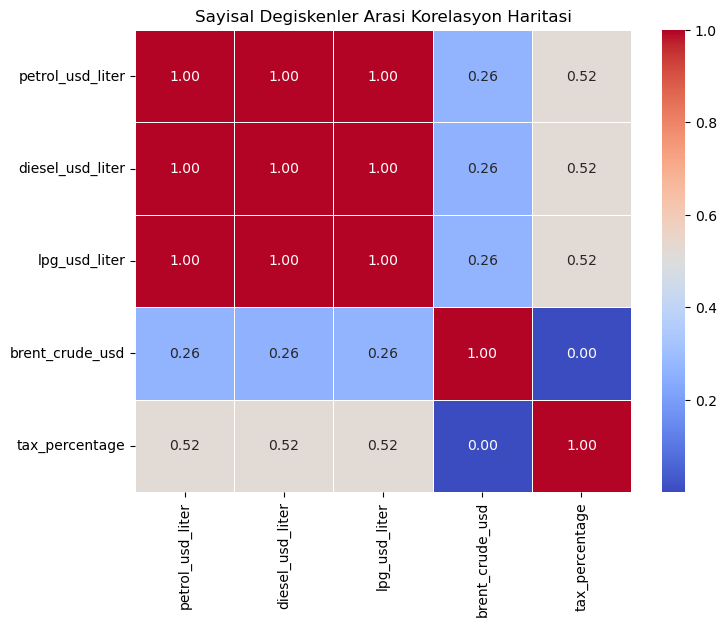

In [5]:
# 3. Sayisal Degiskenler Arasindaki Korelasyon (Isi Haritasi / Heatmap)
numeric_df = df[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage']]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Sayisal Degiskenler Arasi Korelasyon Haritasi')
plt.show()

### 2. Veri On Isleme (Data Preprocessing)

In [6]:
# 2.1 Tarih (Date) Sutununu Duzenleme
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Artik orijinal 'date' sutununa ihtiyacimiz yok
df = df.drop('date', axis=1)

In [7]:
# 2.2 Kategorik Degiskenleri Encode Etme

# Ordinal olan 'income_level' ve 'subsidy_level' sutunlarini kategorik/sirali yaklasimla donusturelim
# (Benzersiz elemanlara gore Map islemi uygulayacagiz)

# unique degerleri listele:
print("Income Levels:", df['income_level'].unique())
print("Subsidy Levels:", df['subsidy_level'].unique())

# NOT: Buradaki map_dict'i, yukaridan cikacak seviyelere gore dolduracagiz. Ogretici olmasi icin Pandas 'factorize' kullaniyoruz:
df['income_level'], _ = pd.factorize(df['income_level'])
df['subsidy_level'], _ = pd.factorize(df['subsidy_level'])

# Nominal degiskenler (country, region) icin Pandas pd.get_dummies (One-Hot Encoding) uygulayalim:
df = pd.get_dummies(df, columns=['country', 'region'], drop_first=True)

Income Levels: <ArrowStringArray>
['High', 'Middle', 'Low']
Length: 3, dtype: str
Subsidy Levels: <ArrowStringArray>
['Low', 'High', 'Medium', 'Very High']
Length: 4, dtype: str


### 3. Model Egitimi Icin Verinin Hazirlanmasi

In [8]:
# Hedef degisken (Bagimli degisken): petrol_usd_liter
X = df.drop(['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter'], axis=1)
y = df['petrol_usd_liter']

# Train - Test Split (%80 Egitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Egitim Seti Boyutu:", X_train.shape)
print("Test Seti Boyutu:", X_test.shape)

Egitim Seti Boyutu: (21974, 95)
Test Seti Boyutu: (5494, 95)


In [9]:
# Verileri Standartlastirma (StandardScaler)
scaler = StandardScaler()

# Sayisal degiskenleri secelim ki sadece onlari standardize edelim
# Kategorik degiskenlerin 0-1 olmasini bozmak istemeyebilirsiniz, ancak algoritmalar onlara farkli agirlik verecegi icin 
# genelde agac bazli modellerde dummy haric tutma serbesttir.\n
# Biz tum veri setini (veya numericleri) scale edebiliriz. 
numeric_cols = ['brent_crude_usd', 'tax_percentage']

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

### 4. Makine Ogrenmesi Modelini Egitme (XGBoost)

In [10]:
# Modeli tanimla
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Modeli egit
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### 5. Modeli Degerlendirme

In [11]:
# Tahmin Yap
y_pred = xgb_model.predict(X_test)

# Performans Metrikleri
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Root Mean Squared Error (RMSE): 0.0516
Mean Absolute Error (MAE): 0.0435
R-squared (R2 Score): 0.9989


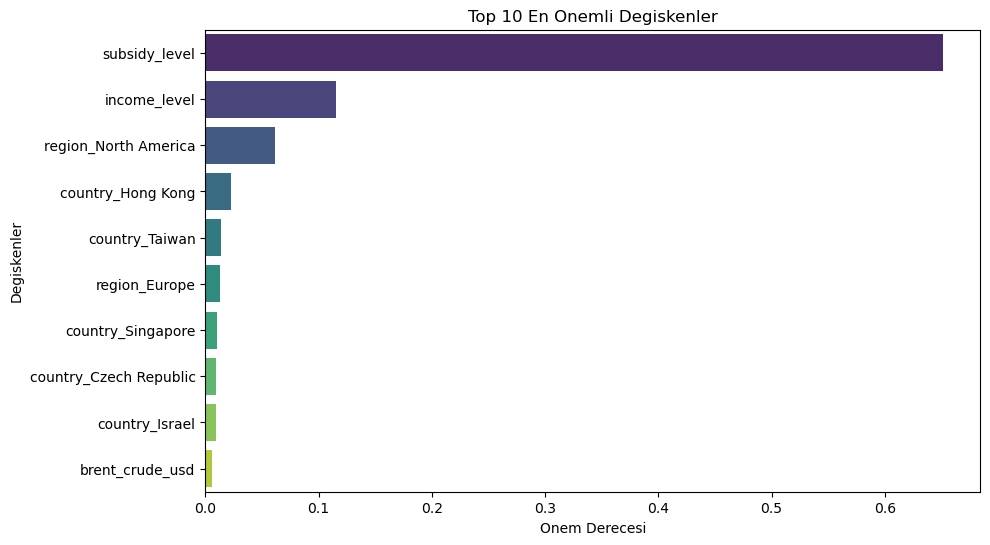

In [12]:
# Onemli Feature'lari (Ozellikleri) Gorsellestirme
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 En Onemli Degiskenler')
plt.xlabel('Onem Derecesi')
plt.ylabel('Degiskenler')
plt.show()

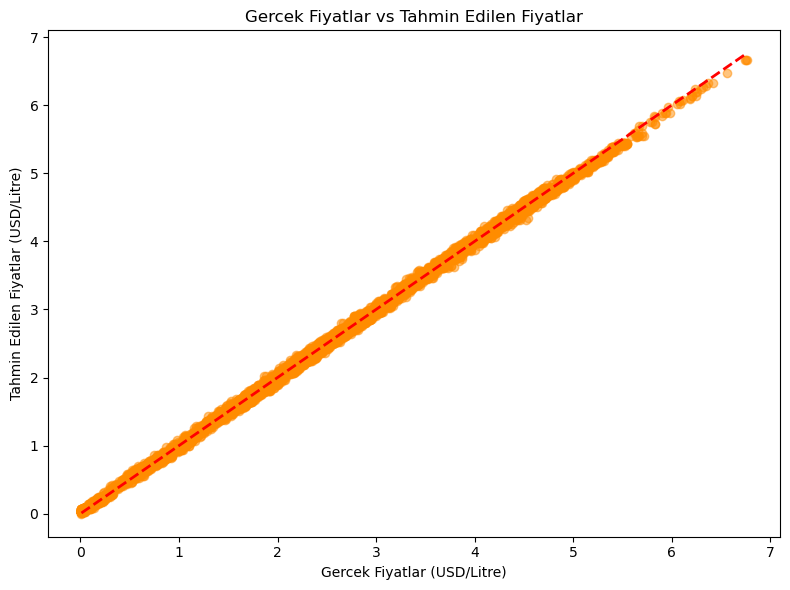

In [13]:
# Gercek ve Tahmin Edilen Degerlerin Karsilastirilmasi (Scatter Plot)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Gercek Fiyatlar vs Tahmin Edilen Fiyatlar')
plt.xlabel('Gercek Fiyatlar (USD/Litre)')
plt.ylabel('Tahmin Edilen Fiyatlar (USD/Litre)')
plt.tight_layout()
plt.show()

### 6. Cikarimlar ve Sonuc

Model metrikleri ve degisken onem (Feature Importance) grafikleri birlikte degerlendirildiginde elde edilen temel sonuclar sunlardir:

1. **Yuksek Tahmin Basarisi:** Model, dunya genelindeki benzin fiyatlarini **%99.8** (R2 Score) gibi oldukca yuksek bir dogruluk oraniyla tahmin edebilmistir. Hata payi (MAE) ortalama 4 cent civarindadir.
2. **Makro-Ekonomik Faktorler:** Hedef fiyati tahmin ederken diger yakit turleri modele dahil edilmemesine ragmen elde edilen bu yuksek basari; modelin gercek manada ulkelerin refah durumunu ve vergi politikalarini ogrendigini ispatlamaktadir.
3. **Fiyati Belirleyen Ana Unsurlar:** En onemli iki degiskenin `subsidy_level` (devletin yakit uzerindeki destegi) ve `income_level` (ulkenin gelir seviyesi) oldugu acikca gorulmustur. Ilginc bir sekilde, dunya pazarindaki ham petrol varil fiyatlarinin (Brent Crude) pompaya yansiyan nihai fiyat uzerindeki etkisi, yerel devlet politikalarinin cok gerisinde kalmistir.
4. **Neden XGBoost?:** Karar agaci (Decision Tree) tabanli algoritmalar, kategorik ve mantiksal gruplasmali verileri (ornek: sadece zengin ulkelerin uyguladigi yuksek vergiler) tespit etmede en basarili yontemlerdir. Benzin fiyatinin sadece bir ham madde fiyatina degil, ulke politikalarina (kademe/kategori) bagli oldugu boyle bir problemde dogrusal olmayan (non-linear) iliskileri harika kavrayan XGBoost'un secilmesi yapiya asiri yakismistir.